In [12]:
# 1/2026
# Focus on the regions identified by Champollion
# Using linear model to test the relationship between shape and other features/diagnostics/CAG etc
# Plotting results

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [5]:
####################################   Quick tests before real run   ###################################
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
sca_targets = [1, 2, 3, 7]
dist_types = ['min', 'max']  
curHem = 'right'

curRegion = 'FPOCalCu' # Calc, FPOCalCu
#curType = 'min'
sca = 1
metric = 'euclidean' # precomputed, euclidean, manhattan or cosine

for sca in sca_targets:
    for curType in dist_types:
        inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
                     rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
        print(inFileName)
        merged_info = pd.read_csv(inFileName)


C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_min_right_euclidean_SCA_1.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_max_right_euclidean_SCA_1.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_min_right_euclidean_SCA_2.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_max_right_euclidean_SCA_2.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_min_right_euclidean_SCA_3.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_max_right_euclidean_SCA_3.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_min_right_euclidean_SCA_7.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_INFO_max_right_euclidean_SCA_7.csv


In [35]:
from pathlib import Path

############ Quick run memo ##########
# 1. define curRegion, curHem, sca_types, dist_types, metrics, shape_measures
# 2. define diag_measures, formula in for loop: be careful if categorical, need to set formula accordingly!
# 3. define SCA_SPECIFIC_DATA, USE_FILTERED_DATA, PATIENT_ONLY depending on SCA-specific, patient-only or not
# 4. inside the loop, change stats model c() if needed

###################################  Define patient/SCA related params ####################################
CONTROL_SITE_RULES = {  # Rulebook: Which sites are allowed for a specific SCA group
    1: ['BIOSCA'],
    2: ['BIOSCA', 'CERMOI'],
    3: ['BIOSCA'],
    7: ['BIOSCA', 'CERMOI']
}

curRegion = 'Calc' #'FPOCalCu', 'Calc'
curHem = 'left'  # NOTE that for the Champollion regions left and right are in separate files
sca_targets = [1, 2, 3, 7]
dist_types = ['min', 'max']  
metrics = ['euclidean'] # precomputed, euclidean
shape_measures = ['iso_dim1_neig5', 'iso_dim2_neig5', 'iso_dim3_neig5','iso_dim4_neig5', 'iso_dim5_neig5', 'iso_dim6_neig5','iso_dim1_neig30', 
                  'iso_dim2_neig30', 'iso_dim3_neig30','iso_dim4_neig30', 'iso_dim5_neig30', 'iso_dim6_neig30']

diag_measures = ['SARA'] # 'SCA', 'CAG', 'SARA'
# filtering pipeline that allows toggling between a specific clinical study focus and a broad dataset view ##
# True when shape measure is calculated by using a specific SCA+Control, not the whole set
SCA_SPECIFIC_DATA = True
# True when need Additional filtering of input data eg. filtering out controls, PATIENT_ONLY set to True
USE_FILTERED_DATA = True  
# True when filtering needed on diag measure is eg. for CAG need to filter out controls
PATIENT_ONLY = True  # Be careful if diag_measure is SCA, here need to set as false 

output_filename = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Stats_printout\LM_summaries.txt'
#####################################################################################################################
results_list = []
for sca in sca_targets:
    for curType in dist_types:
        for metric in metrics:        
            inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
                         rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
            if not Path(inFileName).exists():
                print(f"Skipping: {inFileName} (File not found)")
                continue
            try:
                print(f"Processing SCA {sca} - Type {curType} - Metric {metric}")
                cur_info = pd.read_csv(inFileName, index_col=0)
    
                ################  filtering cur_info by center according to SCA type  ################
                allowed_sites = CONTROL_SITE_RULES.get(sca, ['BIOSCA'])
                is_patient = (cur_info['SCA'] == sca)
                is_control = (cur_info['SCA'] == 0) & (cur_info['CodeICM'].isin(allowed_sites))
                condition = is_patient if PATIENT_ONLY else (is_patient | is_control)
                # Decide which dataset to use for the model
                active_df = cur_info[condition].copy() if USE_FILTERED_DATA else cur_info.copy()
                data_label = "FILTERED" if USE_FILTERED_DATA else "FULL DATASET"
    
                ################  Statistical Modeling  ################
                for shape_measure in shape_measures:
                    # Skip if the shape measure isn't in this specific CSV
                    if shape_measure not in active_df.columns:
                        continue   
                    for diag_measure in diag_measures:
                        ########################  Formula  #########################
                        #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)'  # MODIFY: if diag_measure is categorical
                        formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'
                        ########### Fit Model ##########
                        model = smf.ols(formula, data=active_df).fit()
    
                        ########### Find p-value for the diag_measure ###########
                        all_vars = model.pvalues.index
                        matching_keys = [k for k in all_vars if k == diag_measure or k.startswith(f'C({diag_measure})')]
                        if matching_keys:
                            target_key = matching_keys[0]
                            p_val = model.pvalues[target_key]
                        else: # Statistical mute if variable dropped
                            p_val = 1.0      
                        ########### Define Header with significance marker ###########
                        sig_star = "***" if p_val < 0.05 else ""
                        header = (
                            f'{"="*20} {sig_star} {data_label} | SCA:{sca} | {curType} | {metric} {"="*20}\n'
                            f'FILE: {Path(inFileName).name}\n'
                            f'MEASURE: {shape_measure} | p({diag_measure}): {p_val:.6f}\n'
                        )
                        results_list.append({
                            'p_value': p_val,
                            'text_summary': header + model.summary().as_text() + '\n\n'
                        })
            except Exception as e:
                print(f"Error processing {inFileName}: {e}")
############ Output Sorting and Writing #############
results_list.sort(key=lambda x: x['p_value'])
with open(output_filename, 'w') as f_all:
    for item in results_list:
        f_all.write(item['text_summary'])
print(f"Done! Sorted results written to: {output_filename}")

Processing SCA 1 - Type min - Metric euclidean


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\j

Processing SCA 1 - Type max - Metric euclidean
Processing SCA 2 - Type min - Metric euclidean
Processing SCA 2 - Type max - Metric euclidean
Processing SCA 3 - Type min - Metric euclidean


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\j

Processing SCA 3 - Type max - Metric euclidean
Processing SCA 7 - Type min - Metric euclidean


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\j

Processing SCA 7 - Type max - Metric euclidean
Done! Sorted results written to: C:\B_projWIP\proj_ataxia\Champollion\Stats_printout\LM_summaries.txt


In [ ]:
################################  Confirmation and plots  #####################################

In [37]:
############################# Parameter and date preparation for plots ##############################
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
curHem = 'right'

curRegion = 'Calc' # 'POCalCu'
curType = 'min'    
sca = 2
metric = 'Euclidean' #'manhattan'

#inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
#              rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}_iso_u_with_DB_info\{curRegion}'
               rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
print(inFileName)
merged_info = pd.read_csv(inFileName)
#print(merged_info)
merged_info = merged_info[merged_info['subjID'] != '00035NR'] # Calc outlier, SCA2

C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\Calc_iso_u_with_DB_info\Calc_iso_u_INFO_min_right_Euclidean_SCA_2.csv


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\B_projWIP\\proj_ataxia\\Champollion\\AtrilBioscaCermoi_Champollion_Regions\\Calc_iso_u_with_DB_info\\Calc_iso_u_INFO_min_right_Euclidean_SCA_2.csv'

C:\B_projWIP\proj_ataxia\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig5Min_Euclidean.png


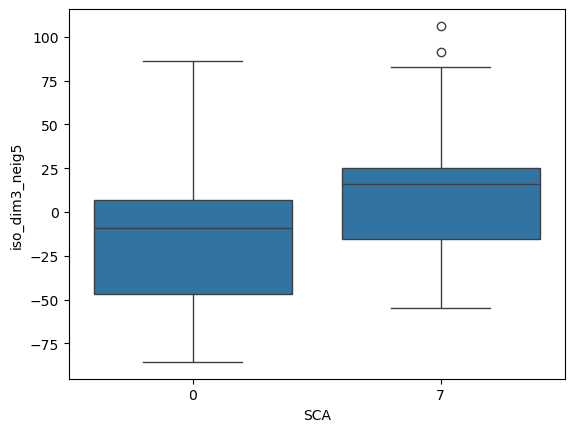

In [75]:
############################  boxplot based on the data defined above  ############################

cur_data = merged_info.copy()  
class_variable = 'SCA'  # Diag, CAG_class, Pyramidal
curX = 'iso_dim3_neig5' # iso3, FPOCalCu
#curX = 'iso_dim1_neig5' # iso1, Calc

sns.boxplot(data=cur_data, x=class_variable, y=curX)


curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig5Min_Euclidean.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.close()

In [101]:
inChampF = rf"\B_projWIP\proj_{curProject}\Champollion\Manhattan\Atril_Biosca_Cermoi_iso_u_with_info_sca_2\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u_INFO.csv"
merged_info = pd.read_csv(inChampF,index_col=0,header=0)

Saving to: C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png


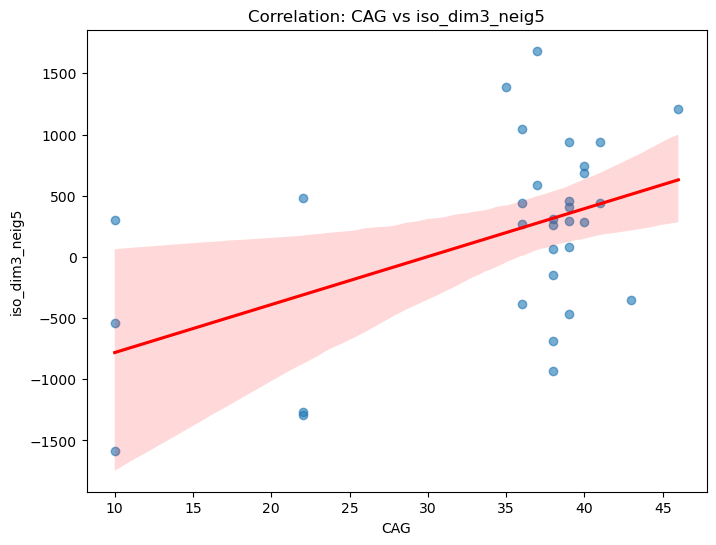

In [111]:
############################  scatter based on the data defined above  ############################

cur_data = merged_info.copy()  
class_variable = 'CAG'  # Independent Variable (X)
curX = 'iso_dim3_neig5' #'iso_dim1_neig5' # Dependent Variable (Y)

# Use regplot to get the scatter points PLUS a regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=cur_data, x=class_variable, y=curX, 
            scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})

# Dynamic title based on your variables
plt.title(f'Correlation: {class_variable} vs {curX}')

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png'
print(f"Saving to: {curPlotName}")

# Uncomment these to save
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.show() # Recommended to see it before closing
#plt.close()

In [39]:
################################  LM tests, parametric  #################################

#diag_measures = ['CAGlong','SARA','INAS']
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        #formula = f'{shape_measure} ~ {diag_measure} + Hemisphere + Age + Sex'
        formula = f'{diag_measure} ~ {shape_measure} + Hemisphere + Age + Sex'        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + Sex'   # effect of diagnosis on shape, Test if shape_measure is explained by diagnosis
        #formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

========================= Results for iso1 and CAGlong ===========================
                            OLS Regression Results                            
Dep. Variable:                CAGlong   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     27.85
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           8.51e-10
Time:                        16:21:02   Log-Likelihood:                -74.305
No. Observations:                  43   AIC:                             156.6
Df Residuals:                      39   BIC:                             163.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------